Hybrid: CNN + Attention

In [ ]:
# Mount Google Drive to access datasets, models, or other files stored in the Drive.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import all requried libraries.

import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
#Connect to OCT dataset folder in Drive.

dataset_path = '/content/drive/My Drive/OCT_Dataset'

In [ ]:
# Initialise ImageDataGenerator for preprocessing and dataset splitting.

data_gen = ImageDataGenerator
 (
    rescale=1./255, # Normalizes pixel values from [0, 255] to [0, 1] to improve model convergence.
    validation_split=0.2 # Reserves 20% of the data for validation.
)

In [ ]:
# Prepare the training dataset using the data generator.

# Images are resized to 128x128 pixels, loaded in batches of 32, and labels are one-hot encoded. Only the 'training' subset is loaded.

train_data = data_gen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 623 images belonging to 3 classes.


In [ ]:
# Prepare the validation dataset using the same configuration.
# Only the 'validation' subset is loaded.

val_data = data_gen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 155 images belonging to 3 classes.


In [ ]:
def attention_block(inputs):

    # 1. Feature transformation - applies a 1x1 convolution to reduce depth while preserving spatial structure.
    x = layers.Conv2D(64, (1, 1), activation='relu')(inputs)

    # 2. Global context aggregation - compresses spatial information into a global descriptor via average pooling.
    x = layers.GlobalAveragePooling2D()(x)

    # 3. Attention weight generation - learns nonlinear relationships between channels to identify importance.
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(inputs.shape[-1], activation='sigmoid')(x) # Output attention weights matching input channels

    # 4. Feature recalibration - scales input features channel-wise using the learned attention weights.
    return layers.Multiply()([inputs, x])

In [ ]:
# Input Layer:
# - 128x128 RGB images (3 channels).
# - Follows preprocessing dimensions from ImageDataGenerator.

input_layer = layers.Input(shape=(128, 128, 3))

# # Convolutional block 1: Initial feature extraction.
x = layers.Conv2D(32, (3, 3), activation='relu')(input_layer)
x = layers.MaxPooling2D((2, 2))(x)
x = attention_block(x)

# Convolutional block 2: Deeper feature extraction.
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = attention_block(x)

# Classification Head:
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
output_layer = layers.Dense(3, activation='softmax')(x)

# Model Assembly:
model = models.Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# Configure training parameters:
# - Optimizer: Adam with default learning rate (0.001).
#   - Adaptive momentum-based gradient descent.
#   - Suitable for attention-based architectures.


model.compile(optimizer=optimizers.Adam(),
              loss='categorical_crossentropy', # Loss: Categorical crossentropy (matches softmax output).
              metrics=['accuracy']) # Metrics: Track accuracy during training.

# Display architecture summary:
# - Shows layer stack with output shapes.
# - Provides total parameter count.
# - Verifies attention block integration.

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 126, 126, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 63, 63, 32)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 63, 63, 64)     │          2,112 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 64)             │              0 │ conv2d_1[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 64)             │          4,160 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32)             │          2,080 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 63, 63, 32)     │              0 │ max_pooling2d[0][0],   │
│                           │                        │                │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 61, 61, 64)     │         18,496 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 30, 30, 64)     │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 30, 30, 64)     │          4,160 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 64)             │              0 │ conv2d_3[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          4,160 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 64)             │          4,160 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 30, 30, 64)     │              0 │ max_pooling2d_1[0][0], │
│                           │                        │                │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 57600)          │              0 │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)      

 Total params: 7,413,539 (28.28 MB)

 Trainable params: 7,413,539 (28.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Execute training with:
# Augmented training batches.
# Initial training cycle set to 10 epochs.
# Validation generator.


history = model.fit
 (
    train_data,
    epochs=10,
    validation_data=val_data
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 382s 19s/step - accuracy: 0.4430 - loss: 1.0014 - val_accuracy: 0.6710 - val_loss: 0.8557
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6430 - loss: 0.8177 - val_accuracy: 0.7226 - val_loss: 0.7035
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.7215 - loss: 0.6331 - val_accuracy: 0.7742 - val_loss: 0.5929
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8169 - loss: 0.4560 - val_accuracy: 0.8000 - val_loss: 0.5540
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8938 - loss: 0.3371 - val_accuracy: 0.7806 - val_loss: 0.6384
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9207 - loss: 0.2376 - val_accuracy: 0.8000 - val_loss: 0.5516
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9434 - loss: 0.1458 - val_accuracy: 0.7806 - val_loss: 0.6265
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9764 - loss: 0.0865 - val_accuracy: 0.8194 - val_los

In [ ]:
# Quantitative performance assessment:
# - test_loss: Cross-entropy loss on validation set.
# - test_acc: Classification accuracy.

test_loss, test_acc = model.evaluate(val_data)
print(f"Hybrid Model Test Accuracy: {test_acc:.2f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step - accuracy: 0.8196 - loss: 0.9059
Hybrid Model Test Accuracy: 0.81


In [ ]:
# Generate model predictions on validation set:
# - Returns probability distributions for each class.
# - Uses argmax to get final class predictions (axis=-1 for class dimension).

val_preds = np.argmax(model.predict(val_data), axis=-1)

# Extract true labels from validation generator:
# - Classes property provides the integer-encoded ground truth.
# - Note: Ensure shuffle=False in val_data for correct alignment.

val_labels = val_data.classes

# Get human-readable class names:
# - Extracts from the generator's class_indices mapping.
# - Maintains consistent order with model outputs.

class_names = list(val_data.class_indices.keys())

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


In [ ]:
# Compute Metrics
accuracy = np.mean(val_preds == val_labels)

# Precision, Recall, and F1-score computed for each class individually.
# 'zero_division=0' avoids division errors in case of no predicted samples for a class.

precision = precision_score(val_labels, val_preds, average=None, zero_division=0)
recall = recall_score(val_labels, val_preds, average=None, zero_division=0)
f1 = f1_score(val_labels, val_preds, average=None, zero_division=0)

mse = mean_squared_error(val_labels, val_preds)

auc = roc_auc_score(
    tf.keras.utils.to_categorical(val_labels),
    model.predict(val_data),
    multi_class='ovr'
    )


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step


In [ ]:
# Organise overall performance metrics into a table for better presentation.

performance_data = {
    "Metric": ["Accuracy", "Mean Squared Error (MSE)", "Area Under the ROC Curve (AUC)"],
    "Value": [round(accuracy, 2), round(mse, 2), round(auc, 2)]
}

# Display the overall evaluation metrics in a tabular format.

performance_table = pd.DataFrame(performance_data)
print("\nOverall Performance Metrics:")
print(performance_table.to_string(index=False))


Overall Performance Metrics:
                        Metric  Value
                      Accuracy   0.45
      Mean Squared Error (MSE)   1.56
Area Under the ROC Curve (AUC)   0.48


In [ ]:
# Compile class-wise precision, recall, and F1-score into a structured table.
# Rounding each metric to two decimal places for clarity.

class_metrics = {
    "Class": class_names,
    "Precision": [round(p, 2) for p in precision],
    "Recall": [round(r, 2) for r in recall],
    "F1-Score": [round(f, 2) for f in f1]
}

class_metrics_table = pd.DataFrame(class_metrics)

# Display the class-wise evaluation metrics.
print("\nClass-wise Performance Metrics:")
print(class_metrics_table.to_string(index=False))


Class-wise Performance Metrics:
Class  Precision  Recall  F1-Score
  AMD       0.52    0.49      0.50
  DME       0.21    0.25      0.23
   NO       0.46    0.45      0.46


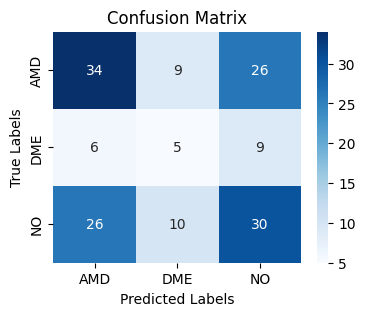

In [ ]:
# Generate and visualise the confusion matrix to assess classification performance.
# Rows represent true labels; columns represent predicted labels.

conf_matrix = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

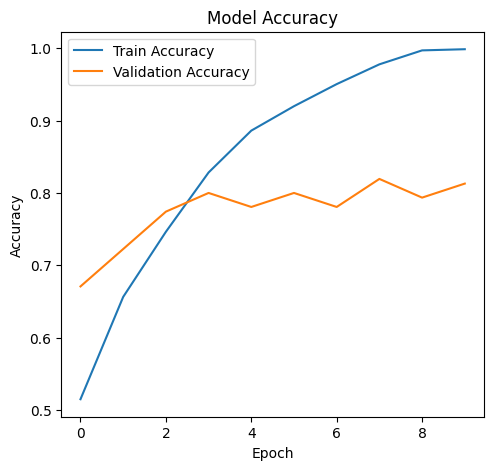

In [ ]:
# Plot training and validation accuracy and loss across epochs to visualize model performance.

plt.figure(figsize=(12, 5))


# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


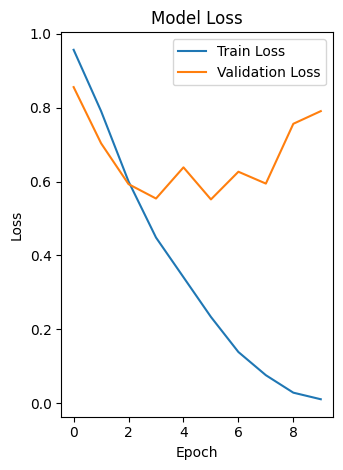

In [ ]:
# Loss Plot

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()